# Naive Bayes Project Exercise

**GOAL: Create a Classification Model that can predict whether or not a person has presence of heart disease based on physical features of that person (age,sex, cholesterol, etc...)**

**Complete the TASKs written in bold below.**

## Imports

**TASK: Run the cell below to import the necessary libraries.**

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data

This database contains 14 physical attributes based on physical testing of a patient. Blood samples are taken and the patient also conducts a brief exercise test. The "goal" field refers to the presence of heart disease in the patient. It is integer (0 for no presence, 1 for presence). In general, to confirm 100% if a patient has heart disease can be quite an invasive process, so if we can create a model that accurately predicts the likelihood of heart disease, we can help avoid expensive and invasive procedures.

Content

Attribute Information:

* age
* sex
* chest pain type (4 values)
* resting blood pressure
* serum cholestoral in mg/dl
* fasting blood sugar > 120 mg/dl
* resting electrocardiographic results (values 0,1,2)
* maximum heart rate achieved
* exercise induced angina
* oldpeak = ST depression induced by exercise relative to rest
* the slope of the peak exercise ST segment
* number of major vessels (0-3) colored by flourosopy
* thal: 3 = normal; 6 = fixed defect; 7 = reversable defect
* target:0 for no presence of heart disease, 1 for presence of heart disease

Original Source: https://archive.ics.uci.edu/ml/datasets/Heart+Disease


**TASK: Run the cell below to read in the data.**

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("heart.csv")

# Show first 5 rows
print(df.head())

# Basic info
print(df.info())

# Summary statistics
print(df.describe())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5 

In [3]:
# Replace '?' with NaN
df.replace("?", pd.NA, inplace=True)

# Convert columns to numeric where needed
df = df.apply(pd.to_numeric, errors='coerce')

# Check missing values
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


# Machine Learning

## Train | Test Split and Scaling

**TASK: Separate the features from the labels into 2 objects, X and y.**

In [4]:
# Features (everything except target)
X = df.drop("target", axis=1)

# Target (label)
y = df["target"]

# Check shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (303, 13)
y shape: (303,)


**TASK: Perform a train test split on the data, with the test size of 10% and a random_state of 101.**

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.10,
    random_state=101
)

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [7]:
scaler.fit(X_train)

StandardScaler()

In [8]:
X_train_scaled = scaler.transform(X_train)

In [9]:
X_test_scaled = scaler.transform(X_test)

**TASK: Create a StandardScaler object and normalize the X train and test set feature data. Make sure you only fit to the training data to avoid data leakage.**

## Naive Bayes Model

**TASK: Create Naive Bayes model

In [10]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

In [11]:
nb_model.fit(X_train_scaled, y_train)

GaussianNB()

## Model Performance Evaluation

**TASK: Let's now evaluate your model on the remaining 10% of the data, the test set.**

**TASK: Create the following evaluations:**
* Confusion Matrix Array
* Confusion Matrix Plot
* Classification Report

In [12]:
from sklearn.metrics import confusion_matrix

# Predictions
y_pred_nb = nb_model.predict(X_test_scaled)

# Confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

print(cm_nb)

[[13  2]
 [ 2 14]]


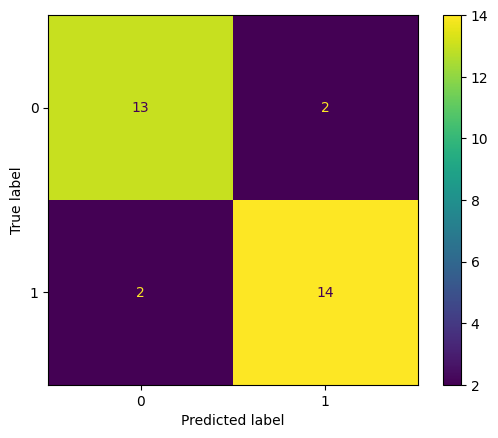

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb)
disp.plot()

plt.show()

In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87        15
           1       0.88      0.88      0.88        16

    accuracy                           0.87        31
   macro avg       0.87      0.87      0.87        31
weighted avg       0.87      0.87      0.87        31



**Final Task: A patient with the following features has come into the medical office:**

    age          48.0
    sex           0.0
    cp            2.0
    trestbps    130.0
    chol        275.0
    fbs           0.0
    restecg       1.0
    thalach     139.0
    exang         0.0
    oldpeak       0.2
    slope         2.0
    ca            0.0
    thal          2.0

**TASK: What does your model predict for this patient? Do they have heart disease? How "sure" is your model of this prediction?**

*For convience, we created an array of the features for the patient above*

In [15]:
import pandas as pd

patient_df = pd.DataFrame([[
    48.0, 0.0, 2.0, 130.0, 275.0, 0.0,
    1.0, 139.0, 0.0, 0.2, 2.0, 0.0, 2.0
]], columns=X.columns)

In [16]:
patient_scaled = scaler.transform(patient_df)

In [17]:
prediction_nb = nb_model.predict(patient_scaled)
print("Prediction:", prediction_nb)

Prediction: [1]


In [18]:
probability_nb = nb_model.predict_proba(patient_scaled)
print("Probabilities:", probability_nb)

Probabilities: [[0.00113704 0.99886296]]


In [19]:
if prediction_nb[0] == 1:
    print(f"Patient is predicted to HAVE heart disease with probability {probability_nb[0][1]:.2f}")
else:
    print(f"Patient is predicted to NOT have heart disease with probability {probability_nb[0][0]:.2f}")

Patient is predicted to HAVE heart disease with probability 1.00
